# The escalated case: which Q2 orders and channels make the gap, and how do you prove the collected figure counts no payment twice?

**Week 2, Tuesday · The escalated case, alone · Kalpa's warehouse, Q2.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Anand signs the page and sends it on to the CEO's Monday numbers, the
collections team rings every order on the unpaid list, and the platform lead receives the repeated
postings. A page that drops an order or keeps a repeat fails each of them.

**The questions on the way.**
1. What did Q2 book, by channel, from orders alone?
2. What did Q2 collect at order grain, and does the count close?
3. Which Q2 orders were never paid?
4. Which payments did the gateway post twice?
5. What does the page say, and which check proves it?

**What you already have.** The six chapters built each move on two invented tables and ran it on the
warehouse. This case asks you to choose each move again on Kalpa's Q2 alone, with nothing traced
first, and a check after each choice. Booked is Monday's figure: 462 Q2 orders and Rs 9,84,00,000.
The gap is booked less collected, and a retried instalment's surplus is what was posted beyond one
payment of it.

**How this solution works.** Every letter is filled in and the notebook runs cold from the top, with
every check passing; under each step, a line says why the other letters fail. The empty cells stay
empty here too, since the lists and figures they print are what the case asks you to find: run them
yourself.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

conn = kit.connect()
conn.autocommit = True


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = [[("NULL" if r[h] is None else kit.rupees(r[h]) if h in money else
              (f"{int(r[h]):,}" if isinstance(r[h], Decimal) and r[h] == r[h].to_integral_value() else str(r[h])))
             for h in heads] for r in rows]
    kit.table(heads, body, caption)


def crore(v):
    return f"{v:.2f}"


def fingerprint(value):
    """A short fingerprint of a result, so a check can compare it without printing the answer."""
    import hashlib
    return hashlib.sha256(repr(value).encode()).hexdigest()[:16]

# Reference figures for the checks, computed once by a route no choice below uses: each paid order's
# posted cash, capped at what it was booked for, as chapter 3's second route did.
REF = run("""
WITH posted AS (SELECT order_id, sum(amount) AS amount FROM payments GROUP BY order_id)
SELECT sum(least(p.amount, o.amount)) AS collected,
       coalesce(sum(o.amount - p.amount) FILTER (WHERE p.amount < o.amount), 0) AS paid_short
FROM orders o
JOIN posted p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'""")[0]
print("Connected to", kit.WAREHOUSE["dbname"], "with", one("SELECT count(*) FROM orders WHERE quarter = 'Q2'"), "Q2 orders.")

Connected to kalpa with 462 Q2 orders.


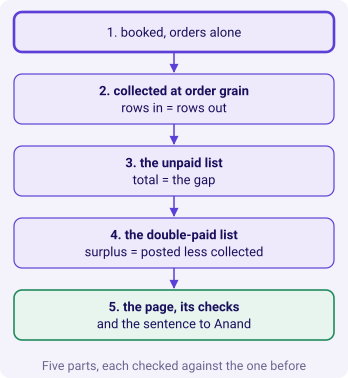

In [2]:
kit.vflow(["1. booked, orders alone", "2. collected at order grain\nrows in = rows out",
           "3. the unpaid list\ntotal = the gap", "4. the double-paid list\nsurplus = posted less collected",
           "5. the page, its checks\nand the sentence to Anand"], kinds=["known", "plain", "plain", "plain", "good"],
          title="Five parts, each checked against the one before")

## Part 1. What did Q2 book, by channel, from orders alone?

Every later figure reconciles to this one. A finance team already holds this number, so at work you
write it down first.

channel,orders_in,booked
app,153,"Rs 4,25,90,270"
store,159,"Rs 3,21,48,730"
web,150,"Rs 2,36,61,000"


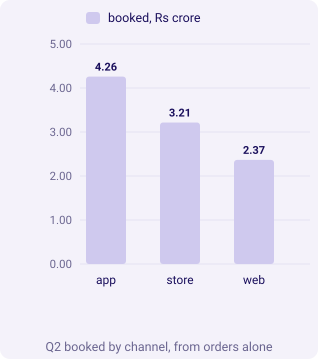

In [3]:
# TODO 1. Which rows give the baseline that booked is reconciled to?
#   a) orders o WHERE o.quarter = 'Q2'
#   b) orders o WHERE o.quarter = 'Q2' AND o.status = 'delivered'
#   c) orders o JOIN payments p ON p.order_id = o.order_id WHERE o.quarter = 'Q2'
#   d) orders o LEFT JOIN payments p ON p.order_id = o.order_id WHERE o.quarter = 'Q2'
options_1 = {'a': "orders o WHERE o.quarter = 'Q2'", 'b': "orders o WHERE o.quarter = 'Q2' AND o.status = 'delivered'", 'c': "orders o JOIN payments p ON p.order_id = o.order_id WHERE o.quarter = 'Q2'", 'd': "orders o LEFT JOIN payments p ON p.order_id = o.order_id WHERE o.quarter = 'Q2'"}
choice_1 = 'a'

baseline = run(f"""
SELECT o.channel, count(*) AS orders_in, sum(o.amount) AS booked
FROM {options_1[choice_1]}
GROUP BY o.channel
ORDER BY o.channel""")
show(baseline, "Part 1: Q2 orders and booked by channel", money=["booked"])
kit.columns([r["channel"] for r in baseline], [("booked, Rs crore", [float(r["booked"]) / 1e7 for r in baseline])],
            fmt=crore, title="Q2 booked by channel, from orders alone")

In [4]:
orders_in = sum(r["orders_in"] for r in baseline)
booked = sum(r["booked"] for r in baseline)
kit.check("the baseline holds all 462 Q2 orders", orders_in == 462, f"{orders_in} orders")
kit.check("booked is Monday's Rs 9,84,00,000", booked == 98400000, kit.rupees(booked))
kit.check("three channels, app, store and web", [r["channel"] for r in baseline] == ["app", "store", "web"])

**Why the other letters fail, TODO 1.** The key is a. b keeps only delivered orders, which is a different definition from Monday's booked; c drops every unpaid order and repeats every two-instalment order; d keeps every order and still repeats the two-instalment ones, so its sum is the fan-out.

## Part 2. What did Q2 collect at order grain, and does the count close?

Payments meet the Q2 orders at the grain and through the join you choose. At work, Anand's analyst
reads this reconciliation before any number, so write it before you run the cell, then fill it in.

- Rows in, from Part 1: ____
- Rows out, from this query: ____
- The difference, and what it is made of: ____

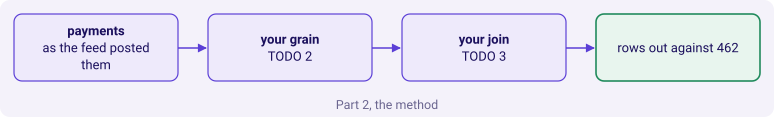

In [5]:
# TODO 2. What grain should the payments CTE have before it meets the orders? (Design)
#   a) every payment row summed per order, as the feed posted it
#   b) each instalment once, then summed per order
#   c) one row per payment, joined straight to the orders
#   d) only the earliest payment row of each order, summed
# TODO 3. Which join keeps every Q2 order on the page?
#   a) JOIN
#   b) RIGHT JOIN
#   c) FULL JOIN
#   d) LEFT JOIN
options_2 = {
    "a": "SELECT order_id, sum(amount) AS collected FROM payments GROUP BY order_id",
    "b": "SELECT order_id, sum(amount) AS collected FROM (SELECT order_id, instalment_no, max(amount) AS amount "
         "FROM payments GROUP BY order_id, instalment_no) i GROUP BY order_id",
    "c": "SELECT order_id, amount AS collected FROM payments",
    "d": "SELECT order_id, sum(amount) AS collected FROM payments WHERE payment_id IN "
         "(SELECT min(payment_id) FROM payments GROUP BY order_id) GROUP BY order_id",
}
options_3 = {'a': 'JOIN', 'b': 'RIGHT JOIN', 'c': 'FULL JOIN', 'd': 'LEFT JOIN'}
choice_2 = 'b'
choice_3 = 'd'

part2 = run(f"""
WITH collected_per_order AS ({options_2[choice_2]})
SELECT o.channel, count(*) AS rows_out, sum(o.amount) AS booked, sum(c.collected) AS collected
FROM (SELECT * FROM orders WHERE quarter = 'Q2') o
{options_3[choice_3]} collected_per_order c ON c.order_id = o.order_id
GROUP BY o.channel
ORDER BY o.channel""")
kit.flow(["payments\nas the feed posted them", "your grain\nTODO 2", "your join\nTODO 3",
          "rows out against 462"], kinds=["plain", "plain", "plain", "good"], title="Part 2, the method")

In [6]:
posted_alone = one("SELECT sum(amount) FROM payments WHERE order_id IN (SELECT order_id FROM orders WHERE quarter = 'Q2')")
rows_out = sum(r["rows_out"] for r in part2)
collected = sum((r["collected"] or 0) for r in part2)
kit.check("rows out equal rows in", rows_out == orders_in, f"{rows_out} rows out, {orders_in} in")
kit.check("booked after the join equals booked from Part 1", sum((r["booked"] or 0) for r in part2) == booked)
kit.check("Part 2's collected equals the reference figure from the setup cell", collected == REF["collected"],
          "equal, figures unprinted")

**Why the other letters fail, TODO 2.** The key is b. a counts a retried instalment twice, so collected carries the repeats; c is no grain at all and fans out; d drops every second instalment, which is real cash.

**Why the other letters fail, TODO 3.** The key is d. a drops the orders nobody paid; b keeps payments and drops unpaid orders; c keeps every Q2 order and adds a row for every other order id the payments table holds, Q1's among them, so rows out exceed rows in.

**Your turn.** Read collected by channel. Type these lines in the empty cell below and run them:

```python
show(part2, "Part 2: booked and collected by channel", money=["booked", "collected"])
```

## Part 3. Which Q2 orders were never paid?

Every Q2 order with no payment at all goes on this list, largest first. The collections team rings
the list at work, and its total must equal the gap, or it is the wrong list.

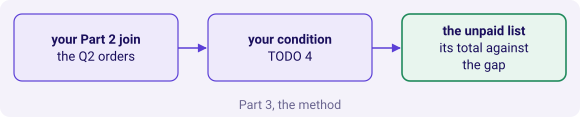

In [7]:
# TODO 4. Which condition keeps only the Q2 orders nothing matched?
#   a) p.order_id IS NULL
#   b) p.paid_date NOT BETWEEN '2026-07-01' AND '2026-09-30'
#   c) p.amount < o.amount
#   d) p.payment_id IS NOT NULL
options_4 = {'a': 'p.order_id IS NULL', 'b': "p.paid_date NOT BETWEEN '2026-07-01' AND '2026-09-30'", 'c': 'p.amount < o.amount', 'd': 'p.payment_id IS NOT NULL'}
choice_4 = 'a'

unpaid = run(f"""
SELECT o.order_id, o.channel, o.status, o.amount AS booked
FROM orders o
{options_3[choice_3]} payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
  AND {options_4[choice_4]}
ORDER BY o.amount DESC""")
kit.flow(["your Part 2 join\nthe Q2 orders", "your condition\nTODO 4", "the unpaid list\nits total against the gap"],
         kinds=["plain", "plain", "good"], title="Part 3, the method")

In [8]:
gap_from_part2 = booked - collected
paid_short = REF["paid_short"]
paid_ids = one("SELECT count(*) FROM payments WHERE order_id = ANY(%s)", ([r["order_id"] for r in unpaid],))
kit.check("the unpaid list's booked total equals the gap from Part 2, less anything paid short",
          sum(r["booked"] for r in unpaid) == gap_from_part2 - paid_short, "equal, figures unprinted")
kit.check("no order on the list has a payment row", paid_ids == 0)
kit.check("every order on the list is a Q2 order", all(r["order_id"] in {x["order_id"] for x in run(
    "SELECT order_id FROM orders WHERE quarter = 'Q2'")} for r in unpaid))

**Why the other letters fail, TODO 4.** The key is a. b is unknown for a NULL date, so it keeps nothing an unpaid order carries; c compares one payment row with the whole order, so it lists the orders paid in instalments and loses the unpaid ones, whose amount is NULL; d keeps the rows that found a payment, the opposite of the list.

**Your turn.** Show the list, and its count and total by channel:

```python
show(unpaid, "Part 3: Q2 orders never paid", money=["booked"])
for ch in ("app", "store", "web"):
    rows = [r for r in unpaid if r["channel"] == ch]
    print(ch, len(rows), kit.rupees(sum(r["booked"] for r in rows)))
```

## Part 4. Which payments did the gateway post twice?

The list holds the payments the gateway posted twice, and nothing a customer legitimately paid. At
work it goes to the platform lead and to Finance, who check with the bank whether a customer was
charged twice.

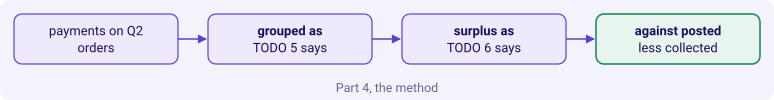

In [9]:
# TODO 5. Which query lists the payments the gateway posted twice?
#   a) GROUP BY p.order_id HAVING count(*) > 1
#   b) GROUP BY p.order_id, p.paid_date HAVING count(*) > 1
#   c) GROUP BY p.order_id, p.instalment_no HAVING count(*) > 1
#   d) WHERE p.instalment_no = 2, one row for each second instalment paid
# TODO 6. How much was posted beyond one payment of each repeated instalment?
#   a) sum(p.amount)
#   b) sum(p.amount) - max(p.amount)
#   c) max(p.amount)
#   d) (count(*) - 1) * sum(p.amount)
options_5 = {
    "a": "GROUP BY p.order_id, o.channel HAVING count(*) > 1",
    "b": "GROUP BY p.order_id, o.channel, p.paid_date HAVING count(*) > 1",
    "c": "GROUP BY p.order_id, o.channel, p.instalment_no HAVING count(*) > 1",
    "d": "AND p.instalment_no = 2 GROUP BY p.order_id, o.channel, p.payment_id",
}
options_6 = {'a': 'sum(p.amount)', 'b': 'sum(p.amount) - max(p.amount)', 'c': 'max(p.amount)', 'd': '(count(*) - 1) * sum(p.amount)'}
choice_5 = 'c'
choice_6 = 'b'

double_paid = run(f"""
SELECT p.order_id, o.channel, count(*) AS times_posted, {options_6[choice_6]} AS posted_twice
FROM payments p
JOIN orders o ON o.order_id = p.order_id
WHERE o.quarter = 'Q2' {options_5[choice_5]}""")
kit.flow(["payments on Q2 orders", "grouped as\nTODO 5 says", "surplus as\nTODO 6 says",
          "against posted\nless collected"], kinds=["plain", "plain", "plain", "good"], title="Part 4, the method")

In [10]:
kit.check("the list's surplus equals posted less collected, both from Part 2's figures",
          sum(r["posted_twice"] for r in double_paid) == posted_alone - collected, "equal, figures unprinted")
kit.check("every row on the list was posted more than once", all(r["times_posted"] > 1 for r in double_paid))
TRIPLE = "(VALUES (1500.00), (1500.00), (1500.00)) AS p(amount)"   # one instalment of 1,500, posted three times
triple = one(f"SELECT {options_6[choice_6]} FROM {TRIPLE}")
triple_ref = one(f"SELECT sum(p.amount) - least(sum(p.amount), 1500.00) FROM {TRIPLE}")
kit.check("your surplus expression agrees with the capped route on an invented instalment posted three times",
          triple == triple_ref, "tested on the invented case")

**Why the other letters fail, TODO 5.** The key is c. a flags every order paid in two instalments; b flags them too, since Kalpa's two instalments are paid on the same day; d lists legitimate second instalments.

**Why the other letters fail, TODO 6.** The key is b. a is everything posted, including the one payment that should be there; c is one payment, which equals the surplus of a pair posted at one amount and nothing else, so an instalment posted three times shows it; d multiplies the whole sum, which doubles the surplus of a pair.

**Your turn.** Show the list and its surplus by channel, and count the payments that match no order,
which the sentence to Anand needs:

```python
show(double_paid, "Part 4: Q2 instalments posted more than once", money=["posted_twice"])
print(one("SELECT count(*) FROM payments p LEFT JOIN orders o ON o.order_id = p.order_id "
          "WHERE o.order_id IS NULL"), "payments match no order")
```

## Part 5. What does the page say, and which check proves it?

The page has one line per channel, with orders, booked, collected, the gap, the unpaid count and the
surplus posted twice. A finance controller signs this page at work, and the check under it lets it
leave the team.

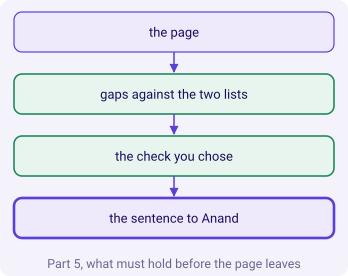

In [11]:
# TODO 7. Which expression gives each channel's gap with the unpaid orders in it?
#   a) sum(booked - collected)
#   b) sum(booked) - sum(coalesce(posted, 0))
#   c) sum(booked - coalesce(collected, 0))
#   d) sum(coalesce(booked, 0) - collected)
# TODO 8. Which check proves that collected holds no payment twice? (Design)
#   a) collected is at most booked on every channel
#   b) collected plus the surplus posted twice equals posted from payments alone
#   c) the gap is not negative on any channel
#   d) every channel appears on the page with at least one order and one payment
options_7 = {'a': 'sum(booked - collected)', 'b': 'sum(booked) - sum(coalesce(posted, 0))', 'c': 'sum(booked - coalesce(collected, 0))', 'd': 'sum(coalesce(booked, 0) - collected)'}
options_8 = {'a': 'collected is at most booked on every channel', 'b': 'collected plus the surplus posted twice equals posted from payments alone', 'c': 'the gap is not negative on any channel', 'd': 'every channel appears on the page with at least one order and one payment'}
choice_7 = 'c'
choice_8 = 'b'

page = run(f"""
WITH collected_per_order AS ({options_2[choice_2]}),
posted_per_order AS (SELECT order_id, sum(amount) AS posted FROM payments GROUP BY order_id),
per_order AS (
    SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
    FROM (SELECT * FROM orders WHERE quarter = 'Q2') o
    {options_3[choice_3]} collected_per_order c ON c.order_id = o.order_id
    {options_3[choice_3]} posted_per_order p ON p.order_id = o.order_id
)
SELECT channel, count(*) AS orders, sum(booked) AS booked, sum(collected) AS collected,
       {options_7[choice_7]} AS gap,
       count(*) FILTER (WHERE collected IS NULL) AS unpaid_orders,
       sum(posted) - sum(collected) AS posted_twice
FROM per_order
GROUP BY channel
ORDER BY channel""")


def run_check(letter, rows, surplus):
    # the four candidate checks, as code, so the choice can be tested on two pages
    if letter == "a":
        return all((r["collected"] or 0) <= (r["booked"] or 0) for r in rows)
    if letter == "b":
        return sum((r["collected"] or 0) for r in rows) + surplus == posted_alone
    if letter == "c":
        return all(r["gap"] is not None and r["gap"] >= 0 for r in rows)
    return len(rows) == 3 and all(r["orders"] > 0 for r in rows)


surplus = sum((r["posted_twice"] or 0) for r in double_paid)
padded = [dict(r, collected=(r["collected"] or 0) + (r["posted_twice"] or 0),
               gap=(r["gap"] or 0) - (r["posted_twice"] or 0)) for r in page]
kit.vflow(["the page", "gaps against the two lists", "the check you chose", "the sentence to Anand"],
          kinds=["plain", "good", "good", "known"], title="Part 5, what must hold before the page leaves")

In [12]:
kit.check("the page's orders add to 462 and its booked to Rs 9,84,00,000",
          sum(r["orders"] for r in page) == 462 and sum((r["booked"] or 0) for r in page) == booked)
kit.check("the page's gaps add to the unpaid list's total plus anything paid short",
          sum(r["gap"] or 0 for r in page) == sum(r["booked"] for r in unpaid) + paid_short, "equal, figures unprinted")
kit.check("the check you chose passes this page and fails a copy of it whose collected is wrong",
          run_check(choice_8, page, surplus) and not run_check(choice_8, padded, surplus), "tested on both pages")

**Why the other letters fail, TODO 7.** The key is c. a and d let an unpaid order's NULL fall out of the sum, so the gap loses exactly the orders it exists to show; b subtracts posted, which still holds the repeats.

**Why the other letters fail, TODO 8.** The key is b. a and c pass a report that dropped unpaid orders, and they can pass one with repeats in it; d says nothing about amounts.

**Your turn.** Show the page, then write the sentence to Anand under it from your own figures; the
count of payments that match no order is the one your Part 4 cell printed:

```python
show(page, "Q2: booked against collected, by channel", money=["booked", "collected", "gap", "posted_twice"])
```

> "Q2 booked Rs 9,84,00,000 and collected Rs ___, each payment counted once. The gap of Rs ___ is
> ___ orders nobody has paid, listed by channel, largest first. Separately, Rs ___ was posted twice
> by gateway retries and ___ payments match no order; both lists go to the platform lead. Every
> figure ties back to the orders and payments tables through checks that have each been seen to
> fail."

## What do you post in the cohort channel?

Post one line: your eight TODO letters in order, no spaces, then your sentence to Anand.

```
Post exactly this shape: xxxxxxxx
```

In [13]:
kit.check_summary()